In [ ]:
import polars as pl

# filter bam files to only references with > 5x coverage
for i in range(1, 2):
    (
        pl.read_csv(f'uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.coverm.tsv', separator='\t', ignore_errors=True, new_columns=['contig_id', 'trimmed_mean', 'mean', 'covered_bases', 'length'])
        .filter(
            ((pl.col('covered_bases') / pl.col('length')) >= 0.8) &
            (pl.col('mean') >= 5)
        )
        [['contig_id']]
        .write_csv(f'uhvdb_sylph_profile/split_{i}/split_{i}_high_coverage_refs.txt', separator='\t', include_header=False)
    )

In [ ]:
%%bash
for i in {1..1}; do \
    samtools view \
        -b \
        -N uhvdb_sylph_profile/split_${i}/split_${i}_high_coverage_refs.txt \
        uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.bam/split_${i}_uhvdb_globdb.contained_genomes.fna.gz.split_${i}_reads_R1.fastq.gz.bam \
        > uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.bam/split_${i}_uhvdb_globdb.high_coverage_refs.bam
done

In [ ]:
%%bash
# filter bam file to only references with > 5x coverage
for i in {1..1}; do
    gunzip uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna.gz

    freebayes \
        -f uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna \
        -F 0.01 \
        -C 1 \
        --pooled-continuous \
        uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.bam/split_${i}_uhvdb_globdb.high_coverage_refs.bam \
        > uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.vcf


    # run floria
    floria -b \
        uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.bam/split_${i}_uhvdb_globdb.high_coverage_refs.bam \
        -v uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.vcf \
        -o uhvdb_sylph_profile/split_${i}/floria \
        -t 48 \
        -r uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna \
        --output-reads \
        --gzip-reads

    gzip uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna


done

In [ ]:
%%bash
python visualize_vartigs.py \
    uhvdb_sylph_profile/split_1/floria/FAHBZ14_vae_8/FAHBZ14_vae_8.vartigs \
    -q 15 \
    -c 5 \
    -l 1000

In [22]:
import glob
for dir in glob.glob('uhvdb_sylph_profile/split_1/floria/v19633-provirus_312_26603/'):
    # extract fastq files passing cov, length, and hapq filters
    parts2assembly = []
    with open(glob.glob(f'{dir}*.vartigs')[0], 'r') as fin:
        for line in fin:
            if line.startswith('>'):
                parts = line.strip().split()
                cov = float(parts[4].split(':')[1])
                length = int(parts[3].split(':')[1].split('-')[1]) - int(parts[3].split(':')[1].split('-')[0]) + 1
                hapq = int(parts[6].split(':')[1])
                seq_id = parts[0].split('>HAP')[1].split('.')[0]
                if cov >= 5 and length >= 1000 and hapq >= 15:
                    parts2assembly.append(f'{dir}short_reads/{seq_id}_part_')
                    print(f"Passing sequence: {seq_id} Cov: {cov} Length: {length} HapQ: {hapq}")

    # assembly with megahit
    for part in parts2assembly:

        !megahit \
            -1 {part}paired1.fastq.gz \
            -2 {part}paired2.fastq.gz \
            -o {part}megahit_output \
            --num-cpu-threads 4 \
            --min-contig-len 1000

        !mv {part}megahit_output/final.contigs.fa \
            {part}megahit_assembled_contigs.fa

        !rm -rf {part}megahit_output

Passing sequence: 2 Cov: 24.568 Length: 24666 HapQ: 60
2025-10-21 10:12:18 - MEGAHIT v1.2.9
2025-10-21 10:12:18 - Using megahit_core with POPCNT and BMI2 support
2025-10-21 10:12:18 - Convert reads to binary library
2025-10-21 10:12:18 - b'INFO  sequence/io/sequence_lib.cpp  :   75 - Lib 0 (/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/v19633-provirus_312_26603/short_reads/2_part_paired1.fastq.gz,/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/v19633-provirus_312_26603/short_reads/2_part_paired2.fastq.gz): pe, 1974 reads, 301 max length'
2025-10-21 10:12:18 - b'INFO  utils/utils.h                 :  152 - Real: 0.0295\tuser: 0.0023\tsys: 0.0047\tmaxrss: 17176'
2025-10-21 10:12:18 - k-max reset to: 141 
2025-10-21 10:12:18 - Start assembly. Number of CPU threads 4 
2025-10-21 10:12:18 - k list: 21,29

In [14]:
parts2assembly

['uhvdb_sylph_profile/split_1/floria/v19633|provirus_312_26603/short_reads/2_part_']

In [ ]:
%%bash
# align contigs to input genomes
# makeblastdb \
#     -in gut_hq_viruses/gut_reps_split/gut_reps.part_001.fna \
#     -dbtype nucl \
#     -out gut_hq_viruses/gut_reps_split/gut_reps.part_001.blastdb

for dir in uhvdb_sylph_profile/split_1/floria/*/; do
    cat ${dir}short_reads/*_part_megahit_assembled_contigs.fa > ${dir}all_megahit_assembled_contigs.fa

    rm -rf ${dir}ragtag_output

    ragtag.py scaffold \
        uhvdb_sylph_profile/split_1/split_1_uhvdb_globdb.contained_genomes.fna.gz \
        ${dir}all_megahit_assembled_contigs.fa \
        -w \
        -o ${dir}ragtag_output \
        -C

    blastn \
        -query ${dir}ragtag_output/ragtag.scaffold.fasta \
        -db gut_hq_viruses/gut_reps_split/gut_reps.part_001.blastdb \
        -outfmt '6  std qlen slen' \
        -max_target_seqs 10000 \
        -out ${dir}blast.tsv \
        -num_threads 4

    python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/anicalc.py \
        -i ${dir}blast.tsv \
        -o ${dir}anicalc.tsv
done

['uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/FAHBZ14_vae_8/short_reads/0_part_',
 'uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/FAHBZ14_vae_8/short_reads/7_part_',
 'uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/FAHBZ14_vae_8/short_reads/20_part_',
 'uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/FAHBZ14_vae_8/short_reads/45_part_',
 'uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/FAHBZ14_vae_8/short_reads/57_part_',
 'uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/FAHBZ14_vae_8/short_reads/68_part_',
 'uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/FAHBZ14_vae_8/short_reads/73_part_',
 'uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_sylph_profile/split_1/floria/FAHBZ14_vae_8/short_reads/97_part_',
 'uhvdb-manuscript/figure_

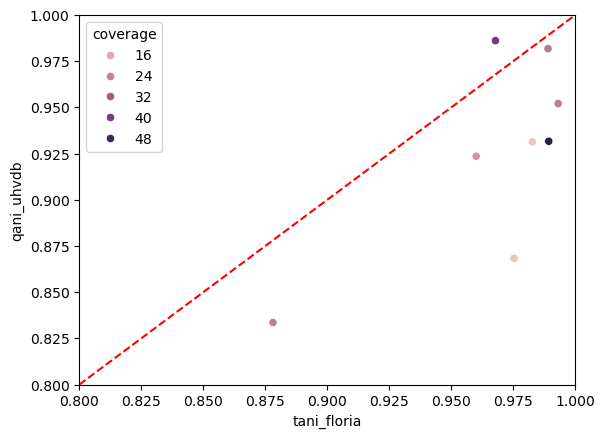

In [15]:
# load list of uhvdb genomes run through floria
import glob
import polars as pl

uhvdb_anicalc = (
    pl.read_csv('uhvdb.anicalc.tsv', separator='\t', ignore_errors=True)
        .with_columns([
            pl.col('tname').alias('uhvdb_id'),
            ((pl.col('pid') * pl.col('tcov'))/10000).alias('tani'),
            ((pl.col('pid') * pl.col('qcov'))/10000).alias('qani'),
        ])
)

plot_df_lst = []

for file in glob.glob('uhvdb_sylph_profile/split_1/floria/*/anicalc.tsv'):
    uhvdb_id = file.split('/')[-2]
    anicalc = (
        pl.read_csv(file, separator='\t', ignore_errors=True)
            .filter(pl.col('pid').is_not_null())
            .with_columns([pl.col('pid').cast(pl.Float64)])
            .with_columns([
                ((pl.col('pid') * pl.col('tcov'))/10000).alias('tani'),
                ((pl.col('pid') * pl.col('qcov'))/10000).alias('qani'),
            ])
            .sort(pl.col('tani'), descending=True)
            .group_by(pl.col('tname'))
            .agg([pl.col('tani').sum().alias('tani'), pl.col('pid').mean().alias('pid'), pl.col('tcov').sum().alias('tcov')])
            .head(1)
            .with_columns([pl.lit(uhvdb_id).alias('uhvdb_id')])
            .join(uhvdb_anicalc, on='uhvdb_id', how='left')
            .filter(pl.col('tname') == pl.col('qname'))
            .rename({'tani':'tani_floria', 'tcov':'tcov_floria', 'pid':'pid_floria', 'qani':'qani_uhvdb', 'qcov':'qcov_uhvdb', 'pid_right':'pid_uhvdb'})
            .join(pl.read_csv('readsim/split_1_reads_cov.txt', separator='\t', ignore_errors=True), left_on='tname', right_on='tname', how='left')
    )
    plot_df_lst.append(anicalc)

plot_df = pl.concat(plot_df_lst)

# plot tani input genomes to  floria vs uhvdb references
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=plot_df,
    y='qani_uhvdb',
    x='tani_floria',
    hue='coverage'
)
# add line along diagonal
plt.plot([0.8, 1], [0.8, 1], color='red', linestyle='--')
plt.xlim(0.8,1)
plt.ylim(0.8,1)
plt.show()

In [3]:
plot_df.sort(pl.col('coverage'))

tname,tani_floria,uhvdb_id,qname,tname_right,num_alns,pid,qcov,tcov,tani_right,qani_uhvdb,genome_length,read_count,coverage
str,f64,str,str,str,i64,f64,f64,f64,f64,f64,i64,i64,f64
"""SRR13172284_k251_124184""",0.664833,"""UHGV-0391979""","""SRR13172284_k251_124184""","""UHGV-0391979""",12,96.31,90.58,90.94,0.875843,0.872376,52753,462,2.627339
"""ERR14118117_k251_167070""",0.102728,"""UHGV-1381292""","""ERR14118117_k251_167070""","""UHGV-1381292""",1,99.7,100.0,99.65,0.993511,0.997,13645,376,8.266764
"""SRR33963773_k251_110002""",0.982703,"""v63055""","""SRR33963773_k251_110002""","""v63055""",2,95.87,97.15,91.79,0.879991,0.931377,17339,592,10.242805
"""SRR34587162_k251_243122""",0.618691,"""FAHBZ14_vae_8""","""SRR34587162_k251_243122""","""FAHBZ14_vae_8""",25,96.16,83.0,86.2,0.828899,0.798128,59472,2118,10.684019
"""SRR33524362_k251_1086""",0.9753,"""v89446""","""SRR33524362_k251_1086""","""v89446""",2,93.43,92.94,94.55,0.883381,0.868338,5947,218,10.997141
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SRR34587184_k251_247474""",0.9931,"""UHGV-1374126""","""SRR34587184_k251_247474""","""UHGV-1374126""",5,98.2,96.95,87.35,0.857777,0.952049,33030,2756,25.031789
"""SRR33686769_k251_202851""",0.6272,"""FHNXY30_vae_1236""","""SRR33686769_k251_202851""","""FHNXY30_vae_1236""",2,99.97,62.46,97.81,0.977807,0.624413,10393,878,25.343982
"""ERR13324396_k251_214758""",0.989,"""UHGV-0167255""","""ERR13324396_k251_214758""","""UHGV-0167255""",2,98.2,99.98,99.98,0.9818036,0.9818036,32589,2920,26.880236
